# Spline Visualization

Synthetic figures for the spline and GAM part of lecture 2.
The same consumer-demand dataset is reused for the GAM-in-action and linear-vs-spline comparison figures.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    ipython = get_ipython()
except NameError:
    ipython = None
if ipython is not None:
    ipython.run_line_magic("config", "InlineBackend.figure_format = 'retina'")

plt.style.use("classic")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.bbox": "tight",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8.5,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.top": False,
        "ytick.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.grid": True,
        "grid.color": "0.88",
        "grid.linewidth": 0.8,
        "grid.alpha": 1.0,
        "figure.dpi": 140,
        "savefig.dpi": 400,
        "lines.linewidth": 2.0,
        "lines.markeredgewidth": 0.0,
        "scatter.edgecolors": "none",
        "patch.edgecolor": "none",
    }
)

BLUE = "tab:blue"
ORANGE = "tab:orange"
GREY = "0.68"
DARK_GREY = "0.35"
POINT_GREY = "0.62"
FIGSIZE = (8.0, 4.5)
WIDE_FIGSIZE = (9.0, 3.6)
OUT_DIR = Path("out") / "spline_visualization"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig: plt.Figure, name: str) -> tuple[Path, Path]:
    pdf_path = OUT_DIR / f"{name}.pdf"
    png_path = OUT_DIR / f"{name}.png"
    fig.savefig(pdf_path)
    fig.savefig(png_path, dpi=400)
    print(f"saved: {pdf_path}")
    print(f"saved: {png_path}")
    return pdf_path, png_path


## Synthetic Consumer-Demand Data

One dataset with three features: temperature, marketing spend, and discount.
The response is additive but nonlinear, which makes it useful for explaining GAMs.


In [2]:
rng = np.random.default_rng(42)
n_samples = 260

temperature = rng.uniform(5, 35, n_samples)
marketing = rng.uniform(0, 12, n_samples)
discount = rng.uniform(0, 30, n_samples)


def temperature_effect(x: np.ndarray) -> np.ndarray:
    return 12.0 * np.exp(-0.5 * ((x - 19.0) / 5.5) ** 2) - 0.12 * (x - 20.0)


def marketing_effect(x: np.ndarray) -> np.ndarray:
    return 7.0 * np.log1p(x) / np.log(13.0) + 0.42 * x


def discount_effect(x: np.ndarray) -> np.ndarray:
    return 3.6 * np.sin((x - 4.0) / 8.0) - 0.014 * (x - 18.0) ** 2


raw_effects = {
    "temperature": temperature_effect(temperature),
    "marketing": marketing_effect(marketing),
    "discount": discount_effect(discount),
}
demand = (
    76.0
    + raw_effects["temperature"] - raw_effects["temperature"].mean()
    + raw_effects["marketing"] - raw_effects["marketing"].mean()
    + raw_effects["discount"] - raw_effects["discount"].mean()
    + rng.normal(0, 3.1, n_samples)
)

data = pd.DataFrame(
    {
        "temperature": temperature,
        "marketing": marketing,
        "discount": discount,
        "demand": demand,
    }
)

FEATURES = ["temperature", "marketing", "discount"]
FEATURE_LABELS = {
    "temperature": "Temperature (C)",
    "marketing": "Marketing spend ($k)",
    "discount": "Discount (%)",
}

data.head()


,temperature,marketing,discount,demand
0,28.218681,1.754079,25.696441,68.873966
1,18.166353,9.895970,11.167847,86.695155
2,30.757938,3.724016,4.608387,63.055718
3,25.921041,1.726463,18.025212,80.787916
4,7.825320,11.051646,3.590177,79.569876


## Slide 56 - Splines, Knots, and Smoothness

A spline is a piecewise polynomial. The knots mark where the polynomial pieces meet.
A smoothness penalty controls whether the fitted curve follows local noise or stays close to a straight trend.


saved: out/spline_visualization/01_spline_knots_and_penalty.pdf
saved: out/spline_visualization/01_spline_knots_and_penalty.png


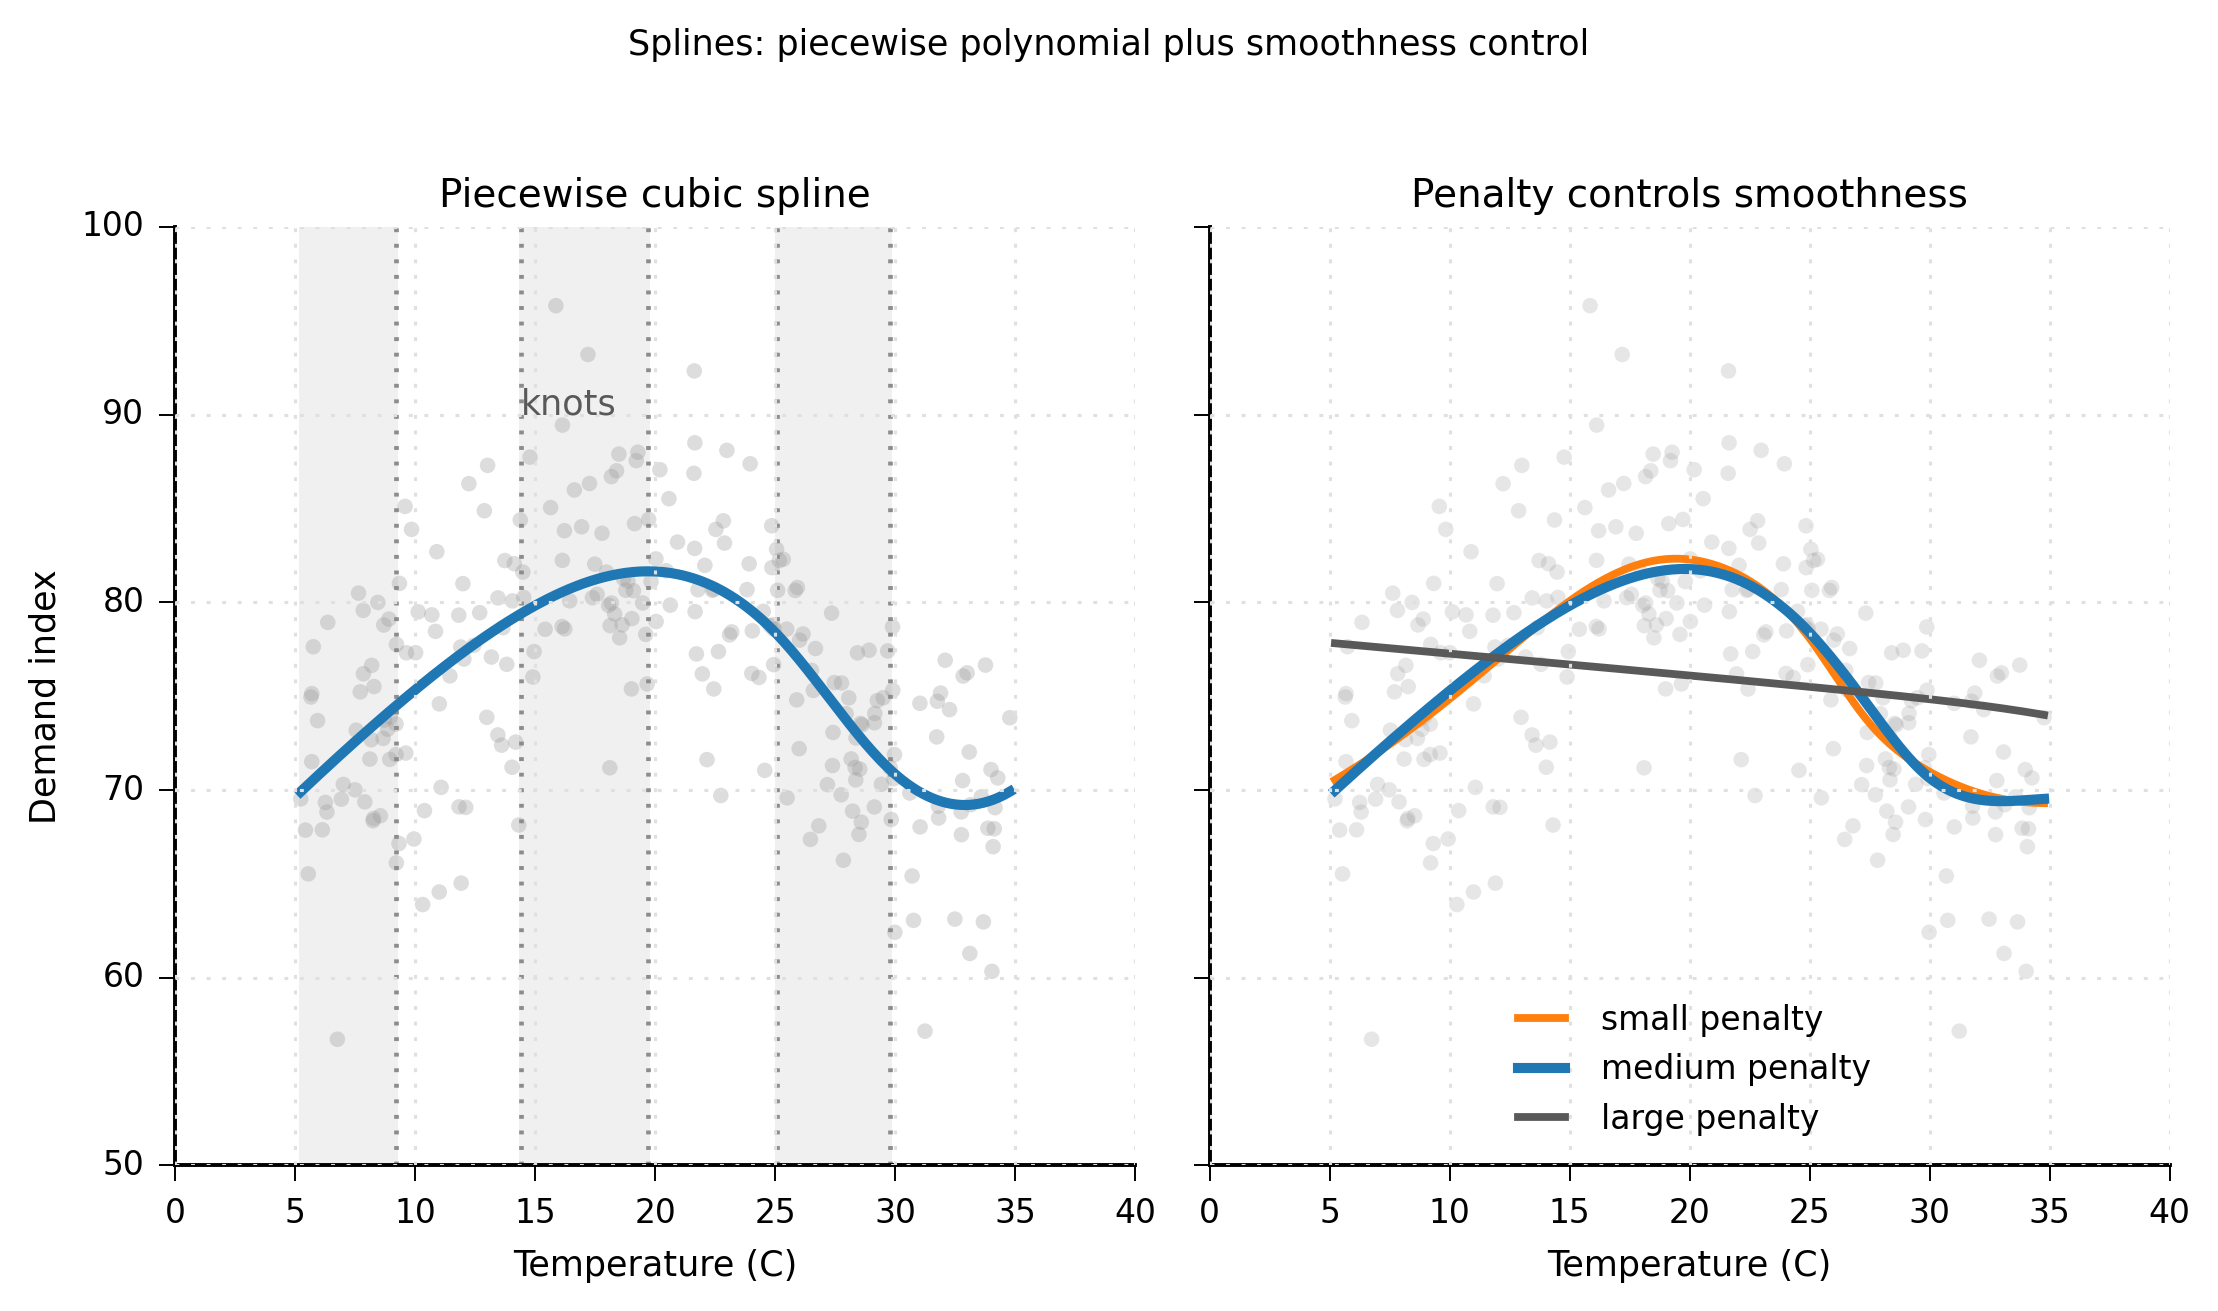

In [3]:
@dataclass
class OneDimensionalSpline:
    x_min: float
    x_scale: float
    knots: np.ndarray
    mean: np.ndarray
    scale: np.ndarray
    beta: np.ndarray


def scaled_x(x: np.ndarray, x_min: float, x_scale: float) -> np.ndarray:
    return (np.asarray(x, dtype=float) - x_min) / x_scale


def raw_cubic_basis_from_scaled(z: np.ndarray, knots: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    truncated = [np.maximum(z - knot, 0.0) ** 3 for knot in knots]
    return np.column_stack([z, z**2, z**3, *truncated])


def fit_1d_spline(x: np.ndarray, y: np.ndarray, lam: float, n_knots: int = 5) -> OneDimensionalSpline:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x_min = float(x.min())
    x_scale = float(x.max() - x_min)
    z = scaled_x(x, x_min, x_scale)
    knots = np.quantile(z, np.linspace(0.15, 0.85, n_knots))
    raw_basis = raw_cubic_basis_from_scaled(z, knots)
    mean = raw_basis.mean(axis=0)
    scale = raw_basis.std(axis=0)
    scale[scale == 0] = 1.0
    basis = (raw_basis - mean) / scale
    design = np.column_stack([np.ones(len(x)), basis])
    penalty = np.eye(design.shape[1])
    penalty[0, 0] = 0.0
    penalty[1, 1] = 0.0
    beta = np.linalg.solve(design.T @ design + lam * penalty, design.T @ y)
    return OneDimensionalSpline(x_min=x_min, x_scale=x_scale, knots=knots, mean=mean, scale=scale, beta=beta)


def predict_1d_spline(model: OneDimensionalSpline, x: np.ndarray) -> np.ndarray:
    z = scaled_x(np.asarray(x, dtype=float), model.x_min, model.x_scale)
    raw_basis = raw_cubic_basis_from_scaled(z, model.knots)
    basis = (raw_basis - model.mean) / model.scale
    design = np.column_stack([np.ones(len(z)), basis])
    return design @ model.beta


x = data["temperature"].to_numpy()
y = data["demand"].to_numpy()
x_grid = np.linspace(x.min(), x.max(), 300)
knot_model = fit_1d_spline(x, y, lam=2.0, n_knots=5)
penalty_models = {
    "small penalty": fit_1d_spline(x, y, lam=0.02, n_knots=8),
    "medium penalty": fit_1d_spline(x, y, lam=2.0, n_knots=8),
    "large penalty": fit_1d_spline(x, y, lam=50000.0, n_knots=8),
}

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, sharey=True)

axes[0].scatter(x, y, s=16, color=POINT_GREY, alpha=0.35, edgecolors="none", linewidths=0)
knot_positions = knot_model.x_min + knot_model.knots * knot_model.x_scale
interval_edges = np.r_[x.min(), knot_positions, x.max()]
for i, (left, right) in enumerate(zip(interval_edges[:-1], interval_edges[1:])):
    if i % 2 == 0:
        axes[0].axvspan(left, right, color="0.94", zorder=0)
for knot in knot_positions:
    axes[0].axvline(knot, color="0.55", linestyle=":", linewidth=1.2)
axes[0].plot(x_grid, predict_1d_spline(knot_model, x_grid), color=BLUE, linewidth=2.6)
axes[0].set_title("Piecewise cubic spline")
axes[0].set_xlabel("Temperature (C)")
axes[0].set_ylabel("Demand index")
axes[0].text(knot_positions[1], 90.0, "knots", color=DARK_GREY)

axes[1].scatter(x, y, s=16, color=POINT_GREY, alpha=0.25, edgecolors="none", linewidths=0)
axes[1].plot(x_grid, predict_1d_spline(penalty_models["small penalty"], x_grid), color=ORANGE, linewidth=2.0, label="small penalty")
axes[1].plot(x_grid, predict_1d_spline(penalty_models["medium penalty"], x_grid), color=BLUE, linewidth=2.6, label="medium penalty")
axes[1].plot(x_grid, predict_1d_spline(penalty_models["large penalty"], x_grid), color=DARK_GREY, linewidth=2.0, label="large penalty")
axes[1].set_title("Penalty controls smoothness")
axes[1].set_xlabel("Temperature (C)")
axes[1].legend(frameon=False, loc="lower center", ncol=1)

fig.suptitle("Splines: piecewise polynomial plus smoothness control", y=1.03)
fig.tight_layout()
save_plot(fig, "01_spline_knots_and_penalty")
plt.show()


## Additive Spline Model

Fit an additive model with one cubic spline block per feature.
The comparison baseline is an ordinary linear model on the same three inputs.


In [4]:
@dataclass
class FeatureSplineSpec:
    name: str
    x_min: float
    x_scale: float
    knots: np.ndarray
    mean: np.ndarray
    scale: np.ndarray


@dataclass
class AdditiveSplineModel:
    specs: list[FeatureSplineSpec]
    beta: np.ndarray


def make_feature_spec(values: np.ndarray, name: str, n_knots: int = 5) -> tuple[FeatureSplineSpec, np.ndarray]:
    values = np.asarray(values, dtype=float)
    x_min = float(values.min())
    x_scale = float(values.max() - x_min)
    z = scaled_x(values, x_min, x_scale)
    knots = np.quantile(z, np.linspace(0.15, 0.85, n_knots))
    raw_basis = raw_cubic_basis_from_scaled(z, knots)
    mean = raw_basis.mean(axis=0)
    scale = raw_basis.std(axis=0)
    scale[scale == 0] = 1.0
    basis = (raw_basis - mean) / scale
    spec = FeatureSplineSpec(name=name, x_min=x_min, x_scale=x_scale, knots=knots, mean=mean, scale=scale)
    return spec, basis


def spline_design(frame: pd.DataFrame, specs: list[FeatureSplineSpec]) -> np.ndarray:
    blocks = []
    for spec in specs:
        z = scaled_x(frame[spec.name].to_numpy(), spec.x_min, spec.x_scale)
        raw_basis = raw_cubic_basis_from_scaled(z, spec.knots)
        blocks.append((raw_basis - spec.mean) / spec.scale)
    return np.column_stack([np.ones(len(frame)), *blocks])


def fit_additive_spline(frame: pd.DataFrame, target: np.ndarray, lam: float = 3.0) -> AdditiveSplineModel:
    specs = []
    blocks = []
    for feature in FEATURES:
        spec, basis = make_feature_spec(frame[feature].to_numpy(), feature)
        specs.append(spec)
        blocks.append(basis)
    design = np.column_stack([np.ones(len(frame)), *blocks])
    penalty = np.eye(design.shape[1])
    penalty[0, 0] = 0.0
    block_width = blocks[0].shape[1]
    for block_start in range(1, design.shape[1], block_width):
        penalty[block_start, block_start] = 0.0
    beta = np.linalg.solve(design.T @ design + lam * penalty, design.T @ target)
    return AdditiveSplineModel(specs=specs, beta=beta)


def predict_additive_spline(model: AdditiveSplineModel, frame: pd.DataFrame) -> np.ndarray:
    return spline_design(frame, model.specs) @ model.beta


def fit_linear_model(frame: pd.DataFrame, target: np.ndarray) -> np.ndarray:
    design = np.column_stack([np.ones(len(frame)), frame[FEATURES].to_numpy()])
    return np.linalg.lstsq(design, target, rcond=None)[0]


def predict_linear_model(beta: np.ndarray, frame: pd.DataFrame) -> np.ndarray:
    design = np.column_stack([np.ones(len(frame)), frame[FEATURES].to_numpy()])
    return design @ beta


spline_model = fit_additive_spline(data, data["demand"].to_numpy(), lam=3.0)
linear_beta = fit_linear_model(data, data["demand"].to_numpy())
reference_values = data[FEATURES].mean()


def feature_grid_frame(feature: str, n: int = 240) -> pd.DataFrame:
    frame = pd.DataFrame({name: np.full(n, reference_values[name]) for name in FEATURES})
    frame[feature] = np.linspace(data[feature].min(), data[feature].max(), n)
    return frame


## Slide 58 - GAMs in Action

Each panel shows the same observed demand values against one feature.
The blue curve is the additive spline model with the other features held at their average values.


saved: out/spline_visualization/02_gams_in_action_synthetic.pdf
saved: out/spline_visualization/02_gams_in_action_synthetic.png


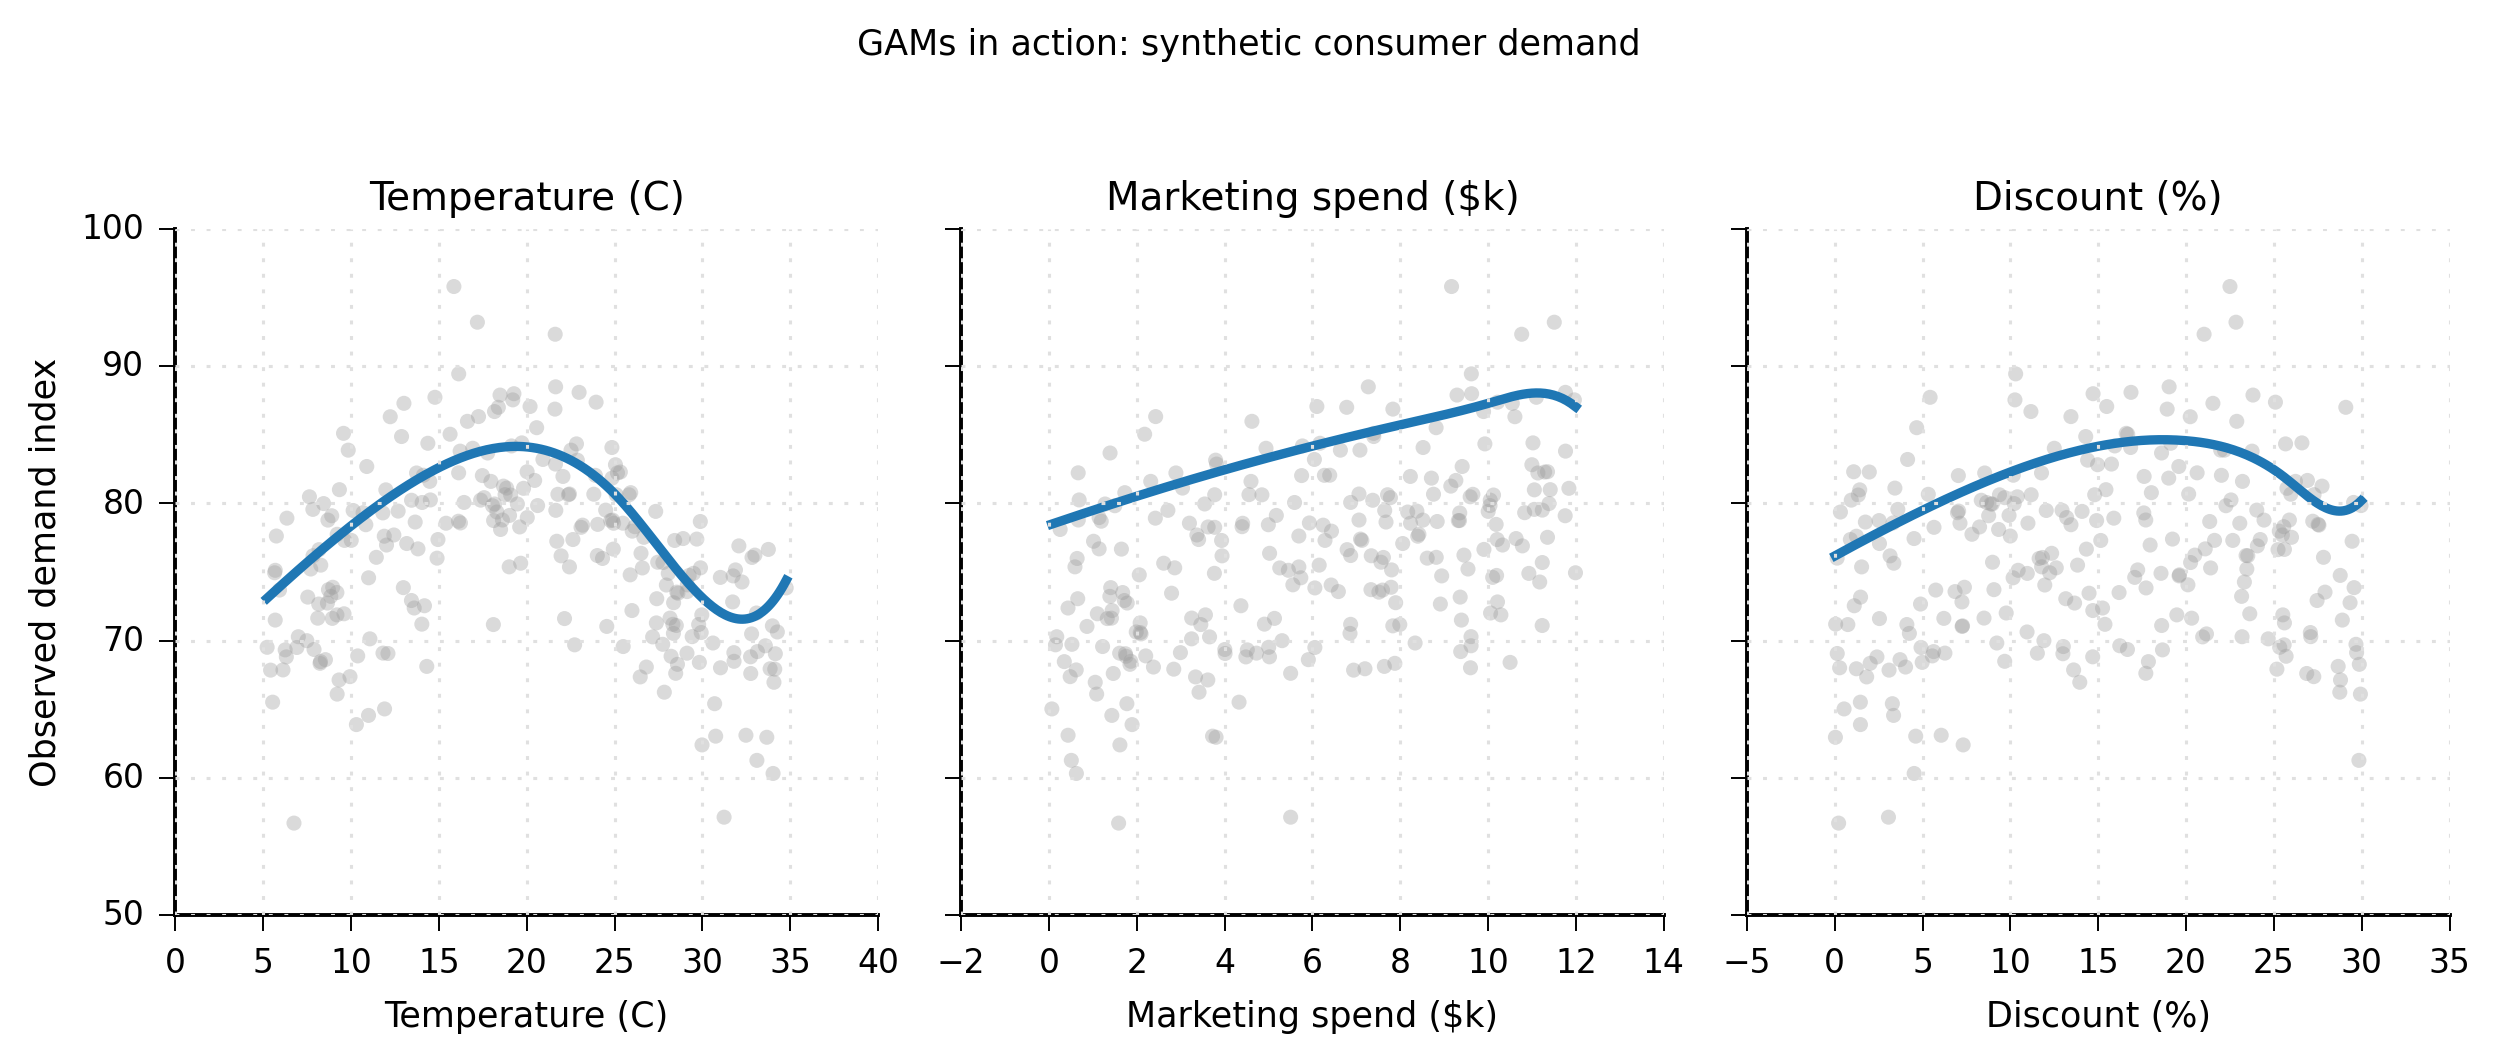

In [5]:
fig, axes = plt.subplots(1, 3, figsize=WIDE_FIGSIZE, sharey=True)

for ax, feature in zip(axes, FEATURES):
    grid_frame = feature_grid_frame(feature)
    ax.scatter(
        data[feature],
        data["demand"],
        color=POINT_GREY,
        alpha=0.38,
        s=15,
        edgecolors="none",
        linewidths=0,
    )
    ax.plot(
        grid_frame[feature],
        predict_additive_spline(spline_model, grid_frame),
        color=BLUE,
        linewidth=2.4,
    )
    ax.set_title(FEATURE_LABELS[feature])
    ax.set_xlabel(FEATURE_LABELS[feature])
axes[0].set_ylabel("Observed demand index")

fig.suptitle("GAMs in action: synthetic consumer demand", y=1.04)
fig.tight_layout()
save_plot(fig, "02_gams_in_action_synthetic")
plt.show()


## Slide 59 - Comparison with Linear Model

The additive spline model captures curvature while the linear model can only tilt a straight plane through the data.


saved: out/spline_visualization/03_spline_vs_linear_synthetic.pdf
saved: out/spline_visualization/03_spline_vs_linear_synthetic.png


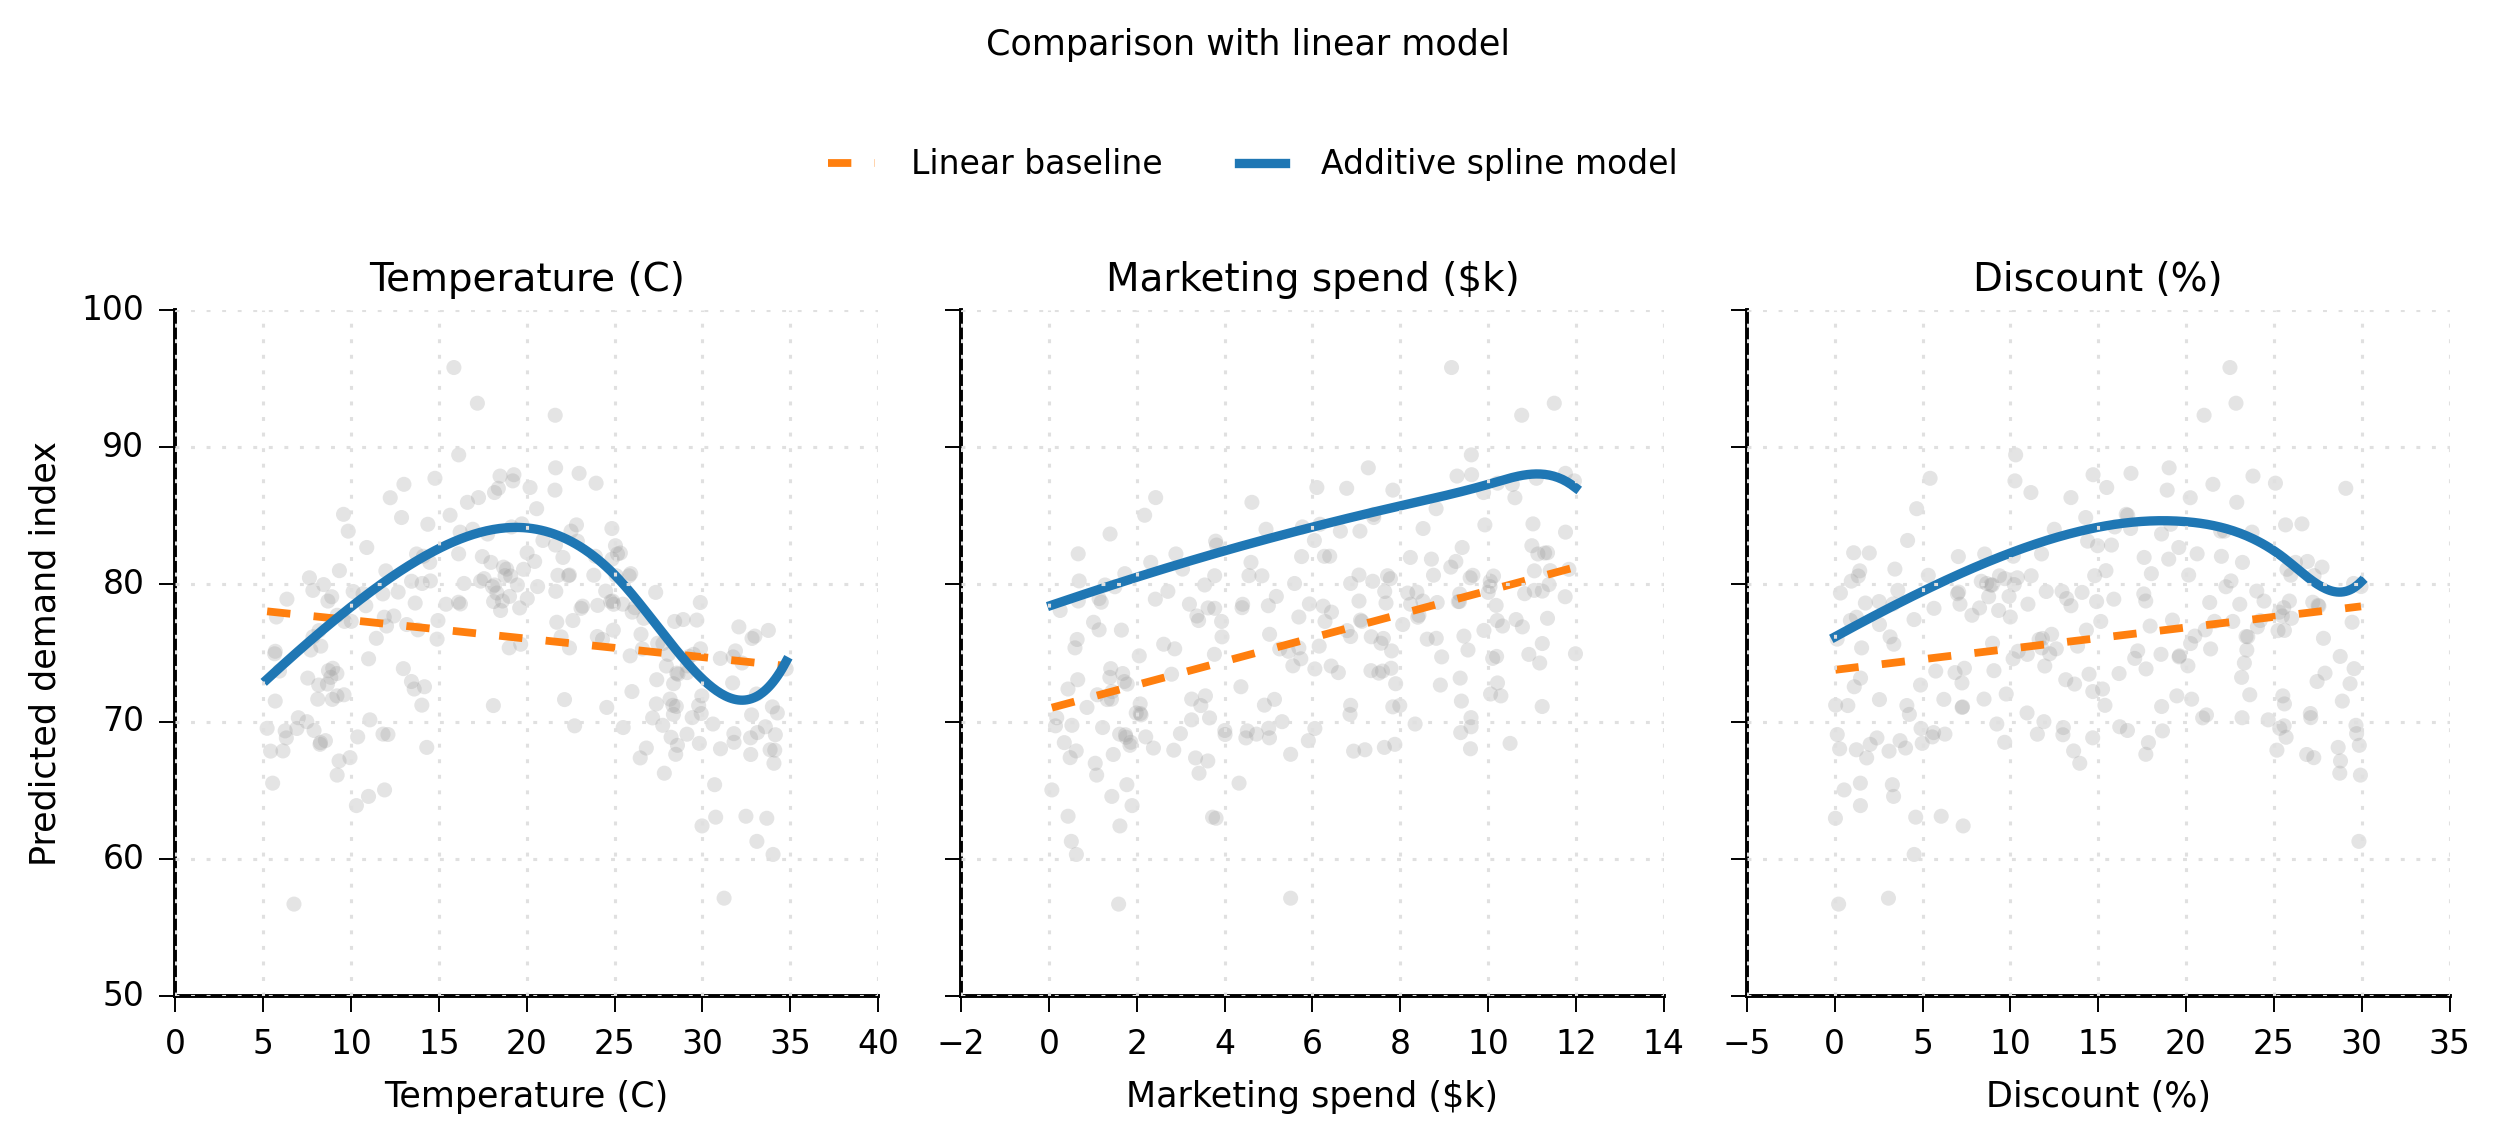

In [6]:
fig, axes = plt.subplots(1, 3, figsize=WIDE_FIGSIZE, sharey=True)

for ax, feature in zip(axes, FEATURES):
    grid_frame = feature_grid_frame(feature)
    ax.scatter(
        data[feature],
        data["demand"],
        color=POINT_GREY,
        alpha=0.28,
        s=15,
        edgecolors="none",
        linewidths=0,
    )
    ax.plot(
        grid_frame[feature],
        predict_linear_model(linear_beta, grid_frame),
        color=ORANGE,
        linestyle="--",
        linewidth=2.0,
        label="Linear baseline",
    )
    ax.plot(
        grid_frame[feature],
        predict_additive_spline(spline_model, grid_frame),
        color=BLUE,
        linewidth=2.4,
        label="Additive spline model",
    )
    ax.set_title(FEATURE_LABELS[feature])
    ax.set_xlabel(FEATURE_LABELS[feature])
axes[0].set_ylabel("Predicted demand index")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Comparison with linear model", y=1.12)
fig.tight_layout()
save_plot(fig, "03_spline_vs_linear_synthetic")
plt.show()
